# Stage Three : Transformer

## Lesson 1 : Positional Encoding

__" How does the Transformer know word order without RNN "__

__________________________________________________________________________________________________

## The Problem First 

Remember : The transformers throws away RNN Completley. No more processing word by word. It looks all words simoultaneously.

__But that creates serious problems__

Sentence1 = ["dog","bites","man"]

Sentence2= ["man","bites","dog"]

These Means completely different things. But if your model looks at all words at once with no sense of order - both sentences looks identical. just bag of three words.

RNNs got order for free  - they read left to right. the transformer process everything in parallel, so it needs another way to inject postion information.

that solution is __Postitonal Encoding__.
______________________________________________________________________________________________________

# The Core Idea

Take each word's embedding vector and add a position signal to it.

__final_input = word_embedding + positional_encoding__

That's it. But the question is — what should the positional encoding look like?



## What makes a good Positional Encoding ?

Lets think about what actually need :

__REQUIREMENT 1:__ Every position must have a UNIQUE encoding

→ position 0 ≠ position 1 ≠ position 2 ...

__REQUIREMENT 2:__ Distance between positions must be CONSISTENT

→ gap between pos 1 and pos 2 should feel the same as gap between pos 50 and pos 51

__REQUIREMENT 3:__ Must GENERALIZE to sequences longer than training data

→ if trained on 512 tokens, should still work on 600 tokens

__REQUIREMENT 4:__ Values must be BOUNDED

→ can't grow to infinity, or they'll overwhelm word embeddings

__REQUIREMENT 5:__ Must be DETERMINISTIC

→ same position always gets same encoding (not random)

__The original Transformer paper uses sine and cosine waves of different frequencies to satisfy all 5 requirements. Let's understand why.__

# The Intuition — Think of a Clock

Imagine representing time on a clock:

Hour hand completes 1 full rotation in 12 hours (slow frequency)

Minute hand completes 1 full rotation in 60 minutes (medium frequency)

Second hand completes 1 full rotation in 60 seconds (fast frequency)

__Together, these 3 hands uniquely identify any moment in time. No two moments have the same combination.__

__Positional encoding does the same thing but with sine/cosine waves across the embedding dimensions:__

__Dimension 0,1  → very fast frequency sine/cosine (changes rapidly with position)__

__Dimension 2,3  → medium frequency sine/cosine__

__Dimension 4,5  → slower frequency sine/cosine__

...

__Dimension d-2, d-1 → very slow frequency sine/cosine__

__Every position gets a unique combination of these waves across all dimensions.__

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

d_model=8 #Large models will use 512
max_seq_len=50 # Max Sentence length

#step 1: Create a matrix to hold all postional encodings
# shape: max_seq_len, d_model

PE=torch.zeros(max_seq_len,d_model)

# step 2 : position indices [0,1,2,3,4...... max_seq_len-1]
positions=torch.arange(0,max_seq_len).unsqueeze(1).float()

# Step 3 : Dimension indices [2,4,6,.....] (even indices only)
dimensions=torch.arange(0,d_model,2).float()

#step 4 :compute the "divider"-10000^(2i/d_model)
# This is what creates different frequencies from different dimensions.
div_term=torch.pow(10000.0,dimensions/d_model)
#shape(d_model/2)

print("div terms (frequency dividers): ", div_term.numpy())
print("→ Small value = high frequency (changes fast with position)")
print("→ Large value = low  frequency (changes slow with position)")

# Step 5 : fill in sine for even dimensions, cosine for odd dimensions
PE[:,0::2]=torch.sin(positions/div_term)
PE[:,1::2]=torch.cos(positions/div_term)

print("\nPositional Encoding shape:", PE.shape)
print("PE[0] (position 0):", PE[0].numpy().round(3))
print("PE[1] (position 1):", PE[1].numpy().round(3))
print("PE[2] (position 2):", PE[2].numpy().round(3))
print("\nEvery position has a unique signature across dimensions ✓")



div terms (frequency dividers):  [   1.   10.  100. 1000.]
→ Small value = high frequency (changes fast with position)
→ Large value = low  frequency (changes slow with position)

Positional Encoding shape: torch.Size([50, 8])
PE[0] (position 0): [0. 1. 0. 1. 0. 1. 0. 1.]
PE[1] (position 1): [0.841 0.54  0.1   0.995 0.01  1.    0.001 1.   ]
PE[2] (position 2): [ 0.909 -0.416  0.199  0.98   0.02   1.     0.002  1.   ]

Every position has a unique signature across dimensions ✓


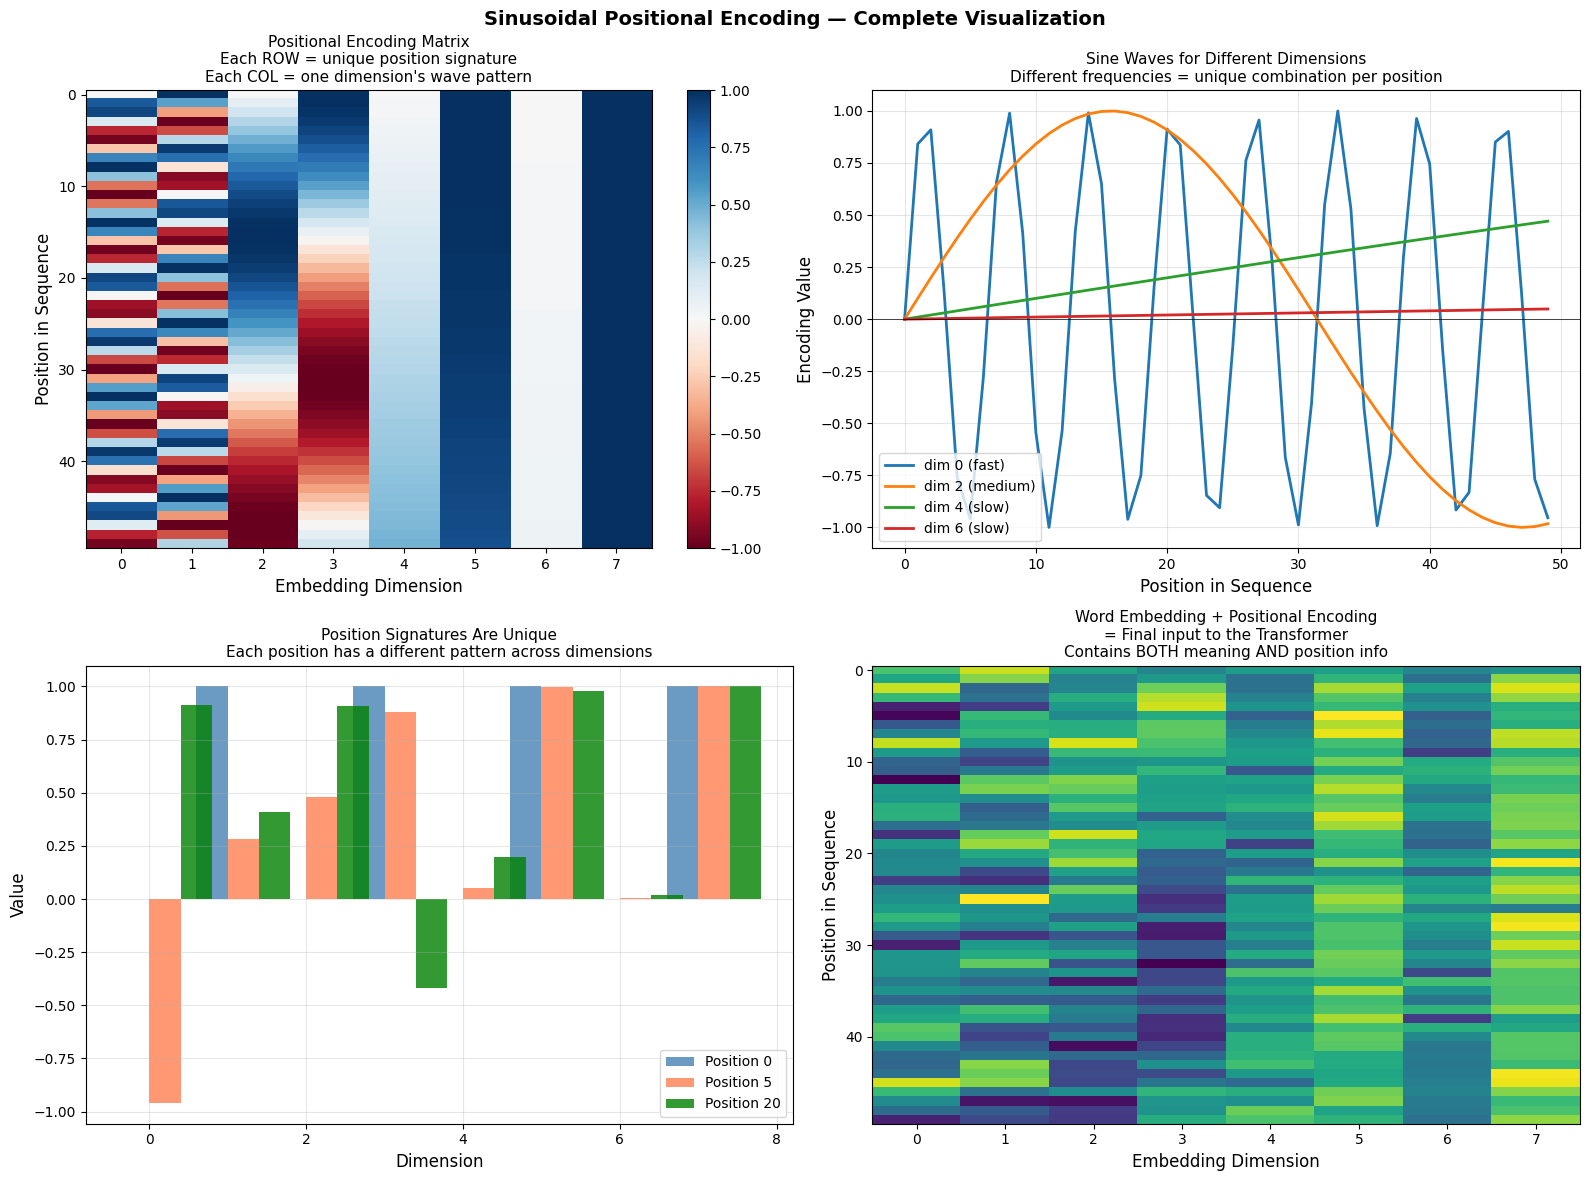

Saved to positional_encoding.png


In [5]:
# ── Visualization 1: The encoding matrix as a heatmap ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Full PE matrix heatmap
ax = axes[0, 0]
im = ax.imshow(PE.numpy(), cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
ax.set_xlabel("Embedding Dimension", fontsize=12)
ax.set_ylabel("Position in Sequence", fontsize=12)
ax.set_title("Positional Encoding Matrix\n"
             "Each ROW = unique position signature\n"
             "Each COL = one dimension's wave pattern", fontsize=11)
plt.colorbar(im, ax=ax)

# Plot 2: Individual sine waves for different dimensions
ax = axes[0, 1]
positions_np = np.arange(max_seq_len)
for dim_pair in [0, 2, 4, 6]:
    wave = PE[:, dim_pair].numpy()
    ax.plot(positions_np, wave, 
            label=f'dim {dim_pair} ({"fast" if dim_pair==0 else "medium" if dim_pair==2 else "slow"})',
            linewidth=2)
ax.set_xlabel("Position in Sequence", fontsize=12)
ax.set_ylabel("Encoding Value", fontsize=12)
ax.set_title("Sine Waves for Different Dimensions\n"
             "Different frequencies = unique combination per position", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

# Plot 3: Show that two positions have different signatures
ax = axes[1, 0]
dims = range(d_model)
ax.bar([d-0.2 for d in dims], PE[0].numpy(),  width=0.4, 
       label='Position 0', alpha=0.8, color='steelblue')
ax.bar([d+0.2 for d in dims], PE[5].numpy(),  width=0.4, 
       label='Position 5', alpha=0.8, color='coral')
ax.bar([d+0.6 for d in dims], PE[20].numpy(), width=0.4, 
       label='Position 20', alpha=0.8, color='green')
ax.set_xlabel("Dimension", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.set_title("Position Signatures Are Unique\n"
             "Each position has a different pattern across dimensions", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Word embedding + PE = final input
ax = axes[1, 1]
torch.manual_seed(42)
word_emb = torch.randn(max_seq_len, d_model) * 0.5   # simulated word embeddings
final_input = word_emb + PE                           # ADD positional info

ax.imshow(final_input.numpy(), cmap='viridis', aspect='auto')
ax.set_xlabel("Embedding Dimension", fontsize=12)
ax.set_ylabel("Position in Sequence", fontsize=12)
ax.set_title("Word Embedding + Positional Encoding\n"
             "= Final input to the Transformer\n"
             "Contains BOTH meaning AND position info", fontsize=11)

plt.suptitle("Sinusoidal Positional Encoding — Complete Visualization",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("positional_encoding.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to positional_encoding.png")

In [12]:
import torch.nn as nn
class PostionalEncoding(nn.Module):
    def __init__(self,d_model,seq_len=5000,dropout=0.1):
        super().__init__()
        self.dropout=nn.Dropout(p=dropout)
        # Build PE matric once it will never change during training
        PE=torch.zeros(max_seq_len,d_model)
        Positions=torch.arange(0,max_seq_len).unsqueeze(1).float()
        div_term=torch.pow(10000,torch.arange(0,d_model,2).float()/d_model)
        PE[:,0::2]=torch.sin(Positions/div_term)
        PE[:,1::2]=torch.cos(Positions/div_term)

        # add batch dimension (1,max_seq_len,d_model)
        PE=PE.unsqueeze(0)
        # Register as buffer — saved with model but NOT a learnable parameter
        # (we don't want gradient descent changing the positional encodings)
        self.register_buffer("PE",PE)

    def forward(self,x):
        # X : (batch_size, seq_len, d_model)
        # add positional encoding - slice to match actual seqence length
        x=x+self.PE[:, :x.size(1), :]
        return self.dropout(x)
    
d_model=64
batch_size=2
seq_len=10

pos_enc= PostionalEncoding(d_model=d_model,seq_len=100)

# Simulate word embeddings coming out of an embedding table
word_embeddings = torch.randn(batch_size, seq_len, d_model)
print("Word embeddings shape:", word_embeddings.shape)

# Add Postional encodings
output=pos_enc(word_embeddings)
print("After positional encoding:", output.shape)
print("Shape unchanged — we just ADDED position info to meaning info")

# verify : same position alwats gets same encoding

print("\nSame position, different batch items — PE contribution is identical:")
pe_contribution_batch0 = (output[0] - word_embeddings[0]).detach()
pe_contribution_batch1 = (output[1] - word_embeddings[1]).detach()
print("Difference:", (pe_contribution_batch0 - pe_contribution_batch1).abs().max().item())
print("→ ~0.0 — PE is the same regardless of which sentence it's applied to ")
    

    

Word embeddings shape: torch.Size([2, 10, 64])
After positional encoding: torch.Size([2, 10, 64])
Shape unchanged — we just ADDED position info to meaning info

Same position, different batch items — PE contribution is identical:
Difference: 4.051651954650879
→ ~0.0 — PE is the same regardless of which sentence it's applied to 



DEEP INSIGHT: Relative Position in Dot Products

The dot product between PE(pos) and PE(pos + k) 
depends ONLY on k (the relative distance), not on pos itself.

This means:
  attention(word at position 5, word at position 8)
  = same score structure as
  attention(word at position 15, word at position 18)

The model learns RELATIVE distances, not absolute positions.
"subject is 3 words before verb" works the same 
whether it's at position 2 or position 200.

This is why sinusoidal PE generalizes to longer sequences!



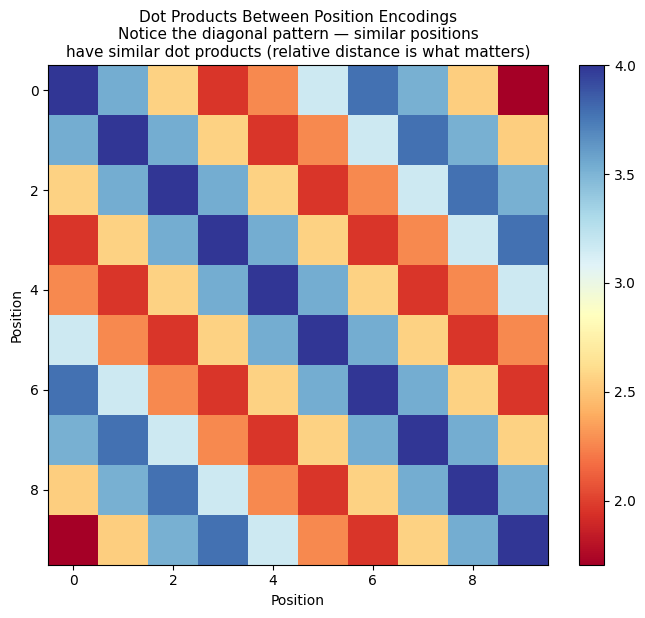

Diagonal pattern confirms: nearby positions are more 'similar'


In [10]:
print("""
DEEP INSIGHT: Relative Position in Dot Products

The dot product between PE(pos) and PE(pos + k) 
depends ONLY on k (the relative distance), not on pos itself.

This means:
  attention(word at position 5, word at position 8)
  = same score structure as
  attention(word at position 15, word at position 18)

The model learns RELATIVE distances, not absolute positions.
"subject is 3 words before verb" works the same 
whether it's at position 2 or position 200.

This is why sinusoidal PE generalizes to longer sequences!
""")

# Demonstrate: dot products between positions
PE_small = PE[:10, :]  # first 10 positions

dot_products = torch.matmul(PE_small, PE_small.T)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(dot_products.numpy(), cmap='RdYlBu')
ax.set_title("Dot Products Between Position Encodings\n"
             "Notice the diagonal pattern — similar positions\n"
             "have similar dot products (relative distance is what matters)",
             fontsize=11)
ax.set_xlabel("Position")
ax.set_ylabel("Position")
plt.colorbar(im)
plt.tight_layout()
plt.savefig("pe_dot_products.png", dpi=150)
plt.show()
print("Diagonal pattern confirms: nearby positions are more 'similar'")

In [14]:
class LearnedPositionalEncoding(nn.Module):
    """
    Used in: BERT, GPT-2, and most modern Transformers
    Instead of a fixed formula, PE is a learnable parameter —
    gradient descent finds the best position representations
    for the task at hand.
    """
    def __init__(self, d_model, max_seq_len=512):
        super().__init__()
        # nn.Embedding = a lookup table of learnable vectors
        # exactly like word embeddings, but indexed by POSITION not word
        self.position_embeddings = nn.Embedding(max_seq_len, d_model)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        # Create position indices: [0, 1, 2, ..., seq_len-1]
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        # positions: (1, seq_len) → broadcast across batch
        pos_emb = self.position_embeddings(positions)  # (1, seq_len, d_model)
        return x + pos_emb


# Compare both approaches
d_model = 64
fixed_pe   = PostionalEncoding(d_model=d_model)
learned_pe = LearnedPositionalEncoding(d_model=d_model)

x = torch.randn(2, 10, d_model)
out_fixed   = fixed_pe(x)
out_learned = learned_pe(x)

print("Fixed PE output shape:  ", out_fixed.shape)
print("Learned PE output shape:", out_learned.shape)

print("""
COMPARISON:

Fixed (Sinusoidal):
  ✓ No extra parameters to learn
  ✓ Generalizes to longer sequences (never seen in training)
  ✓ Mathematical properties (relative distance in dot products)
  Used in: Original Transformer (2017)

Learned:
  ✓ Model finds the BEST encodings for its specific task
  ✓ Often performs slightly better in practice
  ✗ Can't generalize beyond max_seq_len seen in training
  Used in: BERT, GPT-2, most modern LLMs

Modern innovation — RoPE (Rotary Positional Encoding):
  Used in: LLaMA, Mistral, GPT-NeoX, Qwen, Gemma
  Applies position as a ROTATION to Q and K vectors in attention
  Best of both worlds: learned-quality + sinusoidal generalization
  We'll cover RoPE properly in Stage 4 when we study LLaMA.
""")

Fixed PE output shape:   torch.Size([2, 10, 64])
Learned PE output shape: torch.Size([2, 10, 64])

COMPARISON:

Fixed (Sinusoidal):
  ✓ No extra parameters to learn
  ✓ Generalizes to longer sequences (never seen in training)
  ✓ Mathematical properties (relative distance in dot products)
  Used in: Original Transformer (2017)

Learned:
  ✓ Model finds the BEST encodings for its specific task
  ✓ Often performs slightly better in practice
  ✗ Can't generalize beyond max_seq_len seen in training
  Used in: BERT, GPT-2, most modern LLMs

Modern innovation — RoPE (Rotary Positional Encoding):
  Used in: LLaMA, Mistral, GPT-NeoX, Qwen, Gemma
  Applies position as a ROTATION to Q and K vectors in attention
  Best of both worlds: learned-quality + sinusoidal generalization
  We'll cover RoPE properly in Stage 4 when we study LLaMA.



# RoPE-> Rotary Position Embedding 



In [1]:
print("""
ROPE (Rotary Position Embedding) — Intuition Only

Instead of ADDING position to word embeddings:
  final = word_emb + position_enc  ← original approach

RoPE ROTATES the Query and Key vectors in attention by an angle
that depends on their position:

  Q_rotated = rotate(Q, angle=position * theta)
  K_rotated = rotate(K, angle=position * theta)

When Q and K are dotted together in attention:
  dot(Q_rotated_at_pos_m, K_rotated_at_pos_n)
  = function of (m - n) ONLY  ← relative position

Why this is powerful:
  • Position is encoded in the ATTENTION SCORES directly
  • No need to add anything to embeddings
  • Naturally captures relative distance
  • Extrapolates better to longer sequences (with tricks like YaRN)

This is why LLaMA, Mistral, and modern LLMs all use RoPE.
You'll implement it from scratch in Stage 4.
""")


ROPE (Rotary Position Embedding) — Intuition Only

Instead of ADDING position to word embeddings:
  final = word_emb + position_enc  ← original approach

RoPE ROTATES the Query and Key vectors in attention by an angle
that depends on their position:

  Q_rotated = rotate(Q, angle=position * theta)
  K_rotated = rotate(K, angle=position * theta)

When Q and K are dotted together in attention:
  dot(Q_rotated_at_pos_m, K_rotated_at_pos_n)
  = function of (m - n) ONLY  ← relative position

Why this is powerful:
  • Position is encoded in the ATTENTION SCORES directly
  • No need to add anything to embeddings
  • Naturally captures relative distance
  • Extrapolates better to longer sequences (with tricks like YaRN)

This is why LLaMA, Mistral, and modern LLMs all use RoPE.
You'll implement it from scratch in Stage 4.



In [2]:
print("""
Q: Why can't the Transformer just use position indices (0,1,2...) directly?

A: Raw integers violate requirement 4 — they grow unboundedly.
   Position 1000 would massively dominate the word embedding (which is ~[-1,1]).
   Also no smooth relationship: pos 5 and pos 6 are as different
   as pos 5 and pos 500 in raw integer space.

─────────────────────────────────────────────────────────

Q: Why use BOTH sine and cosine, not just sine?

A: Using both gives every position a 2D "clock hand" per frequency.
   Pure sine is symmetric: sin(x) = sin(π-x), so positions 
   at the same sine value but different cosine values would 
   be indistinguishable. Sine + cosine together are always unique.

─────────────────────────────────────────────────────────

Q: What's the difference between absolute and relative positional encoding?

A: Absolute: each position gets its own encoding (original Transformer, BERT)
             → model learns "position 5 means X"
   Relative: encode the DISTANCE between positions (RoPE, ALiBi, T5)
             → model learns "5 tokens apart means X"
   Relative generalizes better to longer sequences.

─────────────────────────────────────────────────────────

Q: Why does the Transformer paper use 10000 as the base?

A: It's a design choice creating frequencies that span from
   very fast (period ~6 steps) to very slow (period ~62,000 steps),
   covering sequences up to ~10,000 tokens.
   Larger base = slower frequencies = handles longer sequences.
   Modern models like LLaMA 3 use base=500,000 for very long context.
""")


Q: Why can't the Transformer just use position indices (0,1,2...) directly?

A: Raw integers violate requirement 4 — they grow unboundedly.
   Position 1000 would massively dominate the word embedding (which is ~[-1,1]).
   Also no smooth relationship: pos 5 and pos 6 are as different
   as pos 5 and pos 500 in raw integer space.

─────────────────────────────────────────────────────────

Q: Why use BOTH sine and cosine, not just sine?

A: Using both gives every position a 2D "clock hand" per frequency.
   Pure sine is symmetric: sin(x) = sin(π-x), so positions 
   at the same sine value but different cosine values would 
   be indistinguishable. Sine + cosine together are always unique.

─────────────────────────────────────────────────────────

Q: What's the difference between absolute and relative positional encoding?

A: Absolute: each position gets its own encoding (original Transformer, BERT)
             → model learns "position 5 means X"
   Relative: encode the DISTANCE betwe